<a href="https://colab.research.google.com/github/r-okotie179/projectTantalus/blob/main/fourier_transforms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Fourier Series
Like the Taylor Series, it acts as a function approximator for both continuous and piecewise functions.

*This is not strictly related to the transforms that I care about, hence I am just copying down the equations and visualising its success on some non-harmonic based equations.*

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt

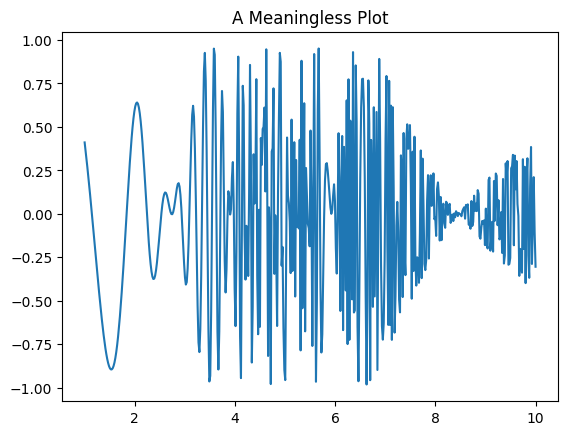

In [ ]:
x = np.linspace(1,10,500)
f = np.sin(np.exp(x)) * np.cos(np.tan(np.log(x))) # known functio
plt.plot(x,f)
plt.title("A Meaningless Plot")
plt.show()

I realised I did not care enough for the series to continue with this: I will now look at the the transform.

### Discrete Fourier Transform

To convert a signal from the time-domain to the frequency domain, the discrete fourier transform (DFT) will be used.

I won't learn the details of it currently (I will be taught about fourier transforms on the course) and will focus on its application now.

$$X_k = \sum^{N-1}_{n=0} x_n e^{-2i\pi\frac{k}{N}n}$$

Only issue would be the imaginary part.

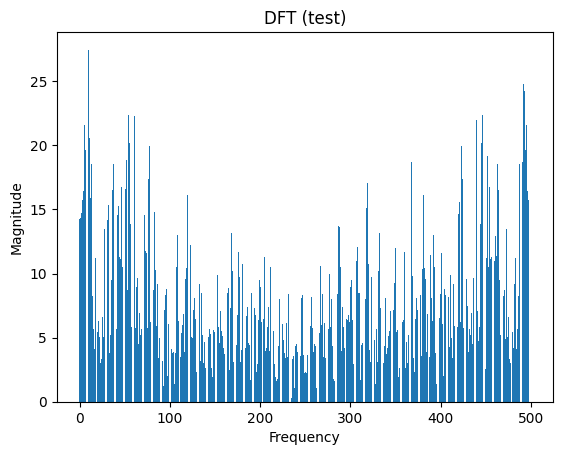

In [ ]:
### test
def sum(x_array, k):
  X_k = 0
  N = len(x_array)
  for n in range(N):
    X_k += x_array[n] * np.exp(-2j*np.pi*(k/N)*n)
  return X_k

def dft(x):
  x = np.array(x)
  k = len(x)
  freq_list = []
  for k in range(len(x)):
    freq = sum(x,k)
    freq_list.append(freq)
  return freq_list

f_list = dft(f)
#print(f_list)

plt.bar(range(len(f)), np.abs(freq_list))
plt.xlabel("Frequency")
plt.ylabel("Magnitude")
plt.title("DFT (test)")

plt.show()

I will now run with with the synthetic data from earlier tests and then see how it segments the data from there.

[np.complex128(68.74176426063791+0j), np.complex128(-52.90122396478055-95.82829447791796j), np.complex128(13.54037155935331+118.19481079950293j), np.complex128(3.7088603021963604+20.556856586598425j), np.complex128(40.298544945405496-22.875104729360388j), np.complex128(-16.734176567039942+24.768336599203923j), np.complex128(-10.22357313746935+3.144154243412822j), np.complex128(-8.47147635596301-33.145450889706225j), np.complex128(0.8564297910974148+20.946226309221235j), np.complex128(-9.937917893165828-2.3598281317048j), np.complex128(10.161051900908776+5.413627030315839j), np.complex128(8.749207693667097-19.10150159312226j), np.complex128(-5.000455717325447-23.50926947756802j), np.complex128(-7.711056867471142-7.107551636404273j), np.complex128(3.03901405698195-15.900365789133293j), np.complex128(8.761527212814245-2.7349708260263097j), np.complex128(5.69490796034525+6.365731833641649j), np.complex128(-16.238820453974387+0.4082623300810927j), np.complex128(-3.4760424602183932+5.1956162

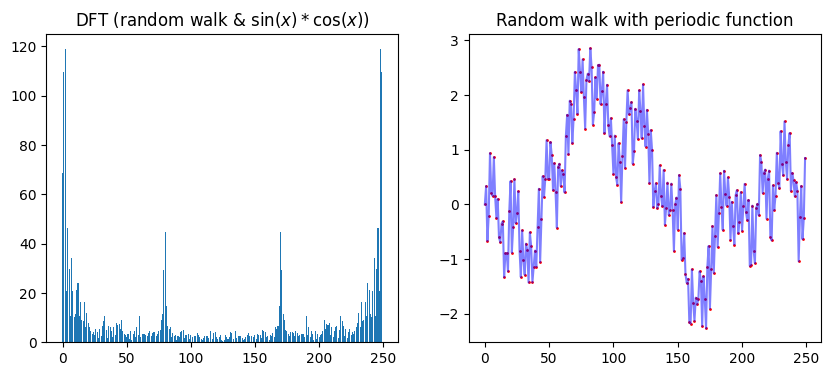

In [ ]:
n = np.arange(0,250)
fx = []
count =0
randwalk = [0]
mixed = []
for i in range(max(n)+1):
  f = np.sin(i) * np.cos(i)
  fx.append(f)
  if i>0:
    count = randwalk[i-1]
    count += np.random.uniform(-.51, .51)
    randwalk.append(count)
  mixed.append((f + count))

dft_mixed = dft(mixed)
print(dft_mixed)

## plot setup
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(10,4))

ax1.bar(n, np.abs(dft_mixed))
#ax1.xlabel("Frequency")
#ax1.ylabel("Magnitude")
ax1.set_title(r"DFT (random walk & $\sin(x) * \cos(x)$)")

ax2.plot(n, mixed, color='b', alpha=0.5)
ax2.scatter(n, mixed, s=1, color='r')
ax2.set_title("Random walk with periodic function")

plt.show()

So now that I have this separation, I should understand what this really means.

I should like to do some filtering of the uncharacteristically large values in frequency (in a static manner).

Additionally, add sliders for the $a\sin(\alpha x) + b\cos(\beta x)$ periodic harmonic just out of interest.

From this, I can then look into predicting/filtering which frequencies are most likely to be periodic shaking and reconstruct the signal after filtering it out (and see how close it is to the original).

**This should take a couple of days.**

-----

After this, I will do things more statistically and dynamic (trying to predict which frequencies to dampen specifically, how much they should be dampened).

#### Clear Next Steps

- understanding IDFT and how to apply it (just learn and copy the formula, derivations not necessary)
- what does the complex results from the DFT actually mean and what is its use (and how to extract this meaning)
- (probability) filtering abnormal periodic/semi-periodic functions from this static plot (that I know things are in)
- what is the distribution of a random walk (first gain intuition with tests of DFT with random walks and see if I can get some conclusion/assumption)
- what aspects of probability is needed for this

In [ ]:
# superposition of random walk, sin(ax), and sin(bx) where both are controlled by sliders

# manual sampling of the signal (with notes on the nuyquist-shannon sampling rate)

# reconstruction of signal (scatter of those discrete points)

# applying DFT on these discrete points

# (every time I use AI for these projects, I will write down the prompt and what I got from it... let's see how that works)